# Assignment 2 — Data Analysis with NumPy & Pandas

## Dataset

This analysis uses the `car_sales_data.csv` dataset containing approximately 50,000 car listing records and 7 columns.

The dataset was obtained from Kaggle.

### Analysis Goals

This notebook will:

1. Inspect and document the dataset schema.
2. Clean missing values, data types, and duplicates.
3. Perform Pandas feature engineering using grouping, aggregation, and reshaping/merging.
4. Apply vectorized NumPy calculations to a numeric feature.
5. Create two visualizations showing meaningful findings.
6. Export a cleaned and feature-engineered dataset.
7. Summarize the findings and limitations.

## Dataset Source

- **Dataset:** Car Sales Dataset
- **File:** `car_sales_data.csv`
- **Source:** Kaggle
- **Source URL:** [PASTE YOUR KAGGLE URL HERE](https://www.kaggle.com/datasets/msnbehdani/mock-dataset-of-second-hand-car-sales)
- **License:** Other (specified in description)
- **Rows reported by source:** approximately 50,000
- **Columns reported by source:** 7

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = "../data/raw/car_sales_data.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (50000, 7)


In [3]:
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset shape:")
print(df.shape)

First 5 rows:


,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101



Column names:
['Manufacturer', 'Model', 'Engine size', 'Fuel type', 'Year of manufacture', 'Mileage', 'Price']

Data types:
Manufacturer               str
Model                      str
Engine size            float64
Fuel type                  str
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object

Dataset shape:
(50000, 7)


In [4]:
print("Missing values by column:")
print(df.isna().sum())

Missing values by column:
Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64


In [5]:
print("Unique values by column:")
print(df.nunique())

Unique values by column:
Manufacturer               5
Model                     15
Engine size               14
Fuel type                  3
Year of manufacture       39
Mileage                44971
Price                  25045
dtype: int64


In [6]:
print("Descriptive statistics:")
display(df.describe(include="all").T)

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Manufacturer,50000,5,Ford,14959,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,50000,15,Mondeo,5058,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine size,50000.0,NaN,NaN,NaN,1.773058,0.734108,1.0,1.4,1.6,2.0,5.0
Fuel type,50000,3,Petrol,25488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year of manufacture,50000.0,NaN,NaN,NaN,2004.20944,9.645965,1984.0,1996.0,2004.0,2012.0,2022.0
Mileage,50000.0,NaN,NaN,NaN,112497.3207,71632.515602,630.0,54352.25,100987.5,158601.0,453537.0
Price,50000.0,NaN,NaN,NaN,13828.90316,16416.681336,76.0,3060.75,7971.5,19026.5,168081.0


In [7]:
df.shape

(50000, 7)

In [8]:
df.columns.tolist()

['Manufacturer',
 'Model',
 'Engine size',
 'Fuel type',
 'Year of manufacture',
 'Mileage',
 'Price']

In [9]:
df.dtypes

Manufacturer               str
Model                      str
Engine size            float64
Fuel type                  str
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object

In [10]:
df.isna().sum()

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

# Task 2 — Data Cleaning

The raw dataset is inspected before any cleaning decisions are applied. Cleaning decisions are based on the observed missing values, data types, and duplicate records. Each decision is documented so that the cleaning process is reproducible and does not silently change the data.

In [11]:
df_clean = df.copy()

print("Raw dataset shape:", df.shape)
print("Cleaning copy shape:", df_clean.shape)

Raw dataset shape: (50000, 7)
Cleaning copy shape: (50000, 7)


In [12]:
missing_counts = df_clean.isna().sum()

print("Missing values before cleaning:")
display(missing_counts)

Missing values before cleaning:


Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

In [13]:
missing_summary = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_percent": (df_clean.isna().mean() * 100).round(2)
})

print("Missing-value summary:")
display(missing_summary)

Missing-value summary:


,missing_count,missing_percent
Manufacturer,0,0.0
Model,0,0.0
Engine size,0,0.0
Fuel type,0,0.0
Year of manufacture,0,0.0
Mileage,0,0.0
Price,0,0.0


In [14]:
print("Data types before cleaning:")
print(df_clean.dtypes)

Data types before cleaning:
Manufacturer               str
Model                      str
Engine size            float64
Fuel type                  str
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object


In [15]:
print("Data type summary:")
display(
    pd.DataFrame({
        "dtype": df_clean.dtypes.astype(str),
        "non_null": df_clean.notna().sum(),
        "unique_values": df_clean.nunique()
    })
)

Data type summary:


,dtype,non_null,unique_values
Manufacturer,str,50000,5
Model,str,50000,15
Engine size,float64,50000,14
Fuel type,str,50000,3
Year of manufacture,int64,50000,39
Mileage,int64,50000,44971
Price,int64,50000,25045


In [16]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 12


In [17]:
print("Duplicate percentage:",
      round((duplicate_count / len(df_clean)) * 100, 2), "%")

Duplicate percentage: 0.02 %


In [18]:
display(df_clean[df_clean.duplicated(keep=False)].head(10))

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
2183,Ford,Mondeo,1.4,Diesel,1987,224569,883
5136,VW,Polo,1.2,Petrol,2003,10000,8024
5426,VW,Polo,1.2,Petrol,2003,10000,8024
5997,Toyota,Yaris,1.0,Petrol,1996,13500,5087
6033,VW,Passat,1.8,Diesel,1996,13500,9394
8881,BMW,Z4,2.4,Petrol,1999,12000,13410
9862,Ford,Mondeo,1.4,Diesel,1987,224569,883
11785,VW,Polo,1.0,Petrol,2000,11500,5950
14745,BMW,Z4,2.4,Petrol,1999,12000,13410
18313,VW,Polo,1.2,Petrol,2021,1000,27901


### Cleaning Decisions

- **Missing values:** The missing-value summary was inspected before cleaning. Missing values will be handled according to the affected column and its meaning rather than being removed automatically.
- **Data types:** The data types were inspected to identify columns that may require conversion before analysis.
- **Duplicates:** 12 exact duplicate rows were identified. These rows will be removed because they duplicate existing observations and could otherwise give repeated records unnecessary weight in the analysis.

In [19]:
before_duplicates = df_clean.shape

df_clean = df_clean.drop_duplicates().copy()

after_duplicates = df_clean.shape

print("Shape before removing duplicates:", before_duplicates)
print("Shape after removing duplicates:", after_duplicates)
print("Duplicates removed:", before_duplicates[0] - after_duplicates[0])

Shape before removing duplicates: (50000, 7)
Shape after removing duplicates: (49988, 7)
Duplicates removed: 12


In [20]:
remaining_duplicates = df_clean.duplicated().sum()

print("Remaining duplicate rows:", remaining_duplicates)

Remaining duplicate rows: 0


In [21]:
print(df_clean.dtypes)

Manufacturer               str
Model                      str
Engine size            float64
Fuel type                  str
Year of manufacture      int64
Mileage                  int64
Price                    int64
dtype: object


In [22]:
print(df_clean.head())

  Manufacturer       Model  Engine size Fuel type  Year of manufacture  \
0         Ford      Fiesta          1.0    Petrol                 2002   
1      Porsche  718 Cayman          4.0    Petrol                 2016   
2         Ford      Mondeo          1.6    Diesel                 2014   
3       Toyota        RAV4          1.8    Hybrid                 1988   
4           VW        Polo          1.0    Petrol                 2006   

   Mileage  Price  
0   127300   3074  
1    57850  49704  
2    39190  24072  
3   210814   1705  
4   127869   4101  


In [23]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['Engine size', 'Year of manufacture', 'Mileage', 'Price']


In [26]:
categorical_columns = df_clean.select_dtypes(include=["object", "str"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Manufacturer', 'Model', 'Fuel type']


In [27]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
['Engine size', 'Year of manufacture', 'Mileage', 'Price']


In [28]:
print("Data types:")
display(df_clean.dtypes.to_frame(name="dtype"))

Data types:


,dtype
Manufacturer,str
Model,str
Engine size,float64
Fuel type,str
Year of manufacture,int64
Mileage,int64
Price,int64


In [29]:
print("Missing values after duplicate removal:")
display(df_clean.isna().sum())

Missing values after duplicate removal:


Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

In [30]:
print("Missing values after duplicate removal:")
display(df_clean.isna().sum())

Missing values after duplicate removal:


Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

In [31]:
missing_after_duplicates = df_clean.isna().sum()

print("Missing values after duplicate removal:")
for column, count in missing_after_duplicates.items():
    print(f"{column}: {count}")

Missing values after duplicate removal:
Manufacturer: 0
Model: 0
Engine size: 0
Fuel type: 0
Year of manufacture: 0
Mileage: 0
Price: 0


In [32]:
print("Data types after cleaning:")
for column, dtype in df_clean.dtypes.items():
    print(f"{column}: {dtype}")

Data types after cleaning:
Manufacturer: str
Model: str
Engine size: float64
Fuel type: str
Year of manufacture: int64
Mileage: int64
Price: int64


# Task 3 – Feature Engineering with GroupBy and Merge

This section creates new features from the cleaned dataset using Pandas transformations. A GroupBy aggregation is used to calculate summary statistics for each manufacturer, and the results are merged back into the original dataset. A pivot table is also created to compare average car prices by manufacturer and fuel type.

In [33]:
print("Shape before feature engineering:", df_clean.shape)

Shape before feature engineering: (49988, 7)


In [34]:
# Calculate summary statistics for each manufacturer

manufacturer_stats = (
    df_clean.groupby("Manufacturer")
    .agg(
        Average_Price=("Price", "mean"),
        Average_Mileage=("Mileage", "mean"),
        Number_of_Cars=("Price", "count")
    )
    .reset_index()
)

print("Manufacturer statistics:")
display(manufacturer_stats.head())

Manufacturer statistics:


,Manufacturer,Average_Price,Average_Mileage,Number_of_Cars
0,BMW,24431.679089,112858.047139,4964
1,Ford,10671.473455,112525.010029,14956
2,Porsche,29103.764661,111638.253737,2609
3,Toyota,14341.099418,111368.922329,12553
4,VW,10361.781497,113511.216423,14906


The GroupBy transformation summarizes the dataset by manufacturer. It calculates the average selling price, average mileage, and the number of cars available for each manufacturer. These statistics provide useful features that can later be used for comparison and analysis.

In [35]:
# Merge manufacturer statistics back into the cleaned dataset

df_featured = df_clean.merge(
    manufacturer_stats,
    on="Manufacturer",
    how="left"
)

print("Shape after merge:", df_featured.shape)

display(df_featured.head())

Shape after merge: (49988, 10)


,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price,Average_Price,Average_Mileage,Number_of_Cars
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,10671.473455,112525.010029,14956
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,29103.764661,111638.253737,2609
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,10671.473455,112525.010029,14956
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,14341.099418,111368.922329,12553
4,VW,Polo,1.0,Petrol,2006,127869,4101,10361.781497,113511.216423,14906


The merge operation adds manufacturer-level statistics to every individual vehicle record. This allows each car to retain its own information while also including summary information about its manufacturer.

In [36]:
price_pivot = pd.pivot_table(
    df_featured,
    values="Price",
    index="Manufacturer",
    columns="Fuel type",
    aggfunc="mean"
)

print("Average price by manufacturer and fuel type")

display(price_pivot)

Average price by manufacturer and fuel type


Fuel type,Diesel,Hybrid,Petrol
Manufacturer,,,
BMW,18148.220392,NaN,26603.381404
Ford,12570.310440,12599.549852,9068.816973
Porsche,28247.090580,NaN,29205.111444
Toyota,NaN,15329.371990,10953.433510
VW,11924.005094,12389.113060,9157.647460


The pivot table compares the average selling price across manufacturers and fuel types. This transformation reshapes the dataset into a format that makes comparisons much easier than using the original table.

In [37]:
print("Final dataset shape after Task 3:", df_featured.shape)

Final dataset shape after Task 3: (49988, 10)


# Task 4 – NumPy-Based Computation

NumPy is used to perform a vectorized computation on the `Price` column. The prices are standardized using the z-score formula. Standardization transforms the values so that they have a mean close to 0 and a standard deviation close to 1, making the feature easier to compare with other variables during analysis or machine learning.

In [38]:
# Convert the Price column to a NumPy array

price_array = df_featured["Price"].to_numpy()

print("NumPy array created successfully.")
print("Array shape:", price_array.shape)

NumPy array created successfully.
Array shape: (49988,)


In [39]:
# Calculate the mean and standard deviation

price_mean = np.mean(price_array)
price_std = np.std(price_array)

# Standardize the values using vectorized operations

price_standardized = (price_array - price_mean) / price_std

print("Standardization completed.")

Standardization completed.


The standardized values were calculated using NumPy broadcasting. No explicit Python loops were used, making the computation efficient and consistent with NumPy best practices.

In [40]:
print("Statistics for the standardized Price values")

print("Mean:", np.mean(price_standardized))
print("Standard Deviation:", np.std(price_standardized))
print("Minimum:", np.min(price_standardized))
print("Maximum:", np.max(price_standardized))

Statistics for the standardized Price values
Mean: 4.122137180331861e-17
Standard Deviation: 1.0
Minimum: -0.8377029645104739
Maximum: 9.395492445562034


In [41]:
# Add the standardized prices to the dataframe

df_featured["Standardized_Price"] = price_standardized

print("New column added successfully.")

display(df_featured.head())

New column added successfully.


,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price,Average_Price,Average_Mileage,Number_of_Cars,Standardized_Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,10671.473455,112525.010029,14956,-0.655095
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,29103.764661,111638.253737,2609,2.185142
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,10671.473455,112525.010029,14956,0.623895
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,14341.099418,111368.922329,12553,-0.738480
4,VW,Polo,1.0,Petrol,2006,127869,4101,10361.781497,113511.216423,14906,-0.592540


In [42]:
print("Current dataframe shape:", df_featured.shape)

print("\nColumns in the dataframe:")

display(df_featured.columns)

Current dataframe shape: (49988, 11)

Columns in the dataframe:


Index(['Manufacturer', 'Model', 'Engine size', 'Fuel type',
       'Year of manufacture', 'Mileage', 'Price', 'Average_Price',
       'Average_Mileage', 'Number_of_Cars', 'Standardized_Price'],
      dtype='str')

# Task 5 – Exploratory Visualization

This section uses Matplotlib to visualize relationships in the cleaned dataset. The charts help identify patterns in vehicle prices, mileage, and manufacturers. Each visualization includes descriptive titles, axis labels, and is saved for inclusion in the final report.

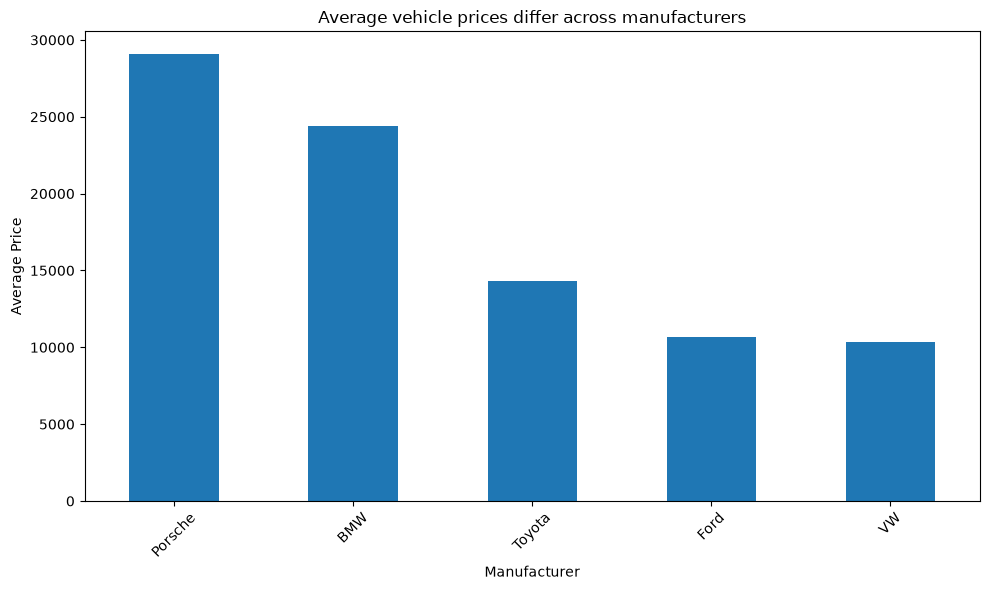

In [43]:
# Calculate average price for each manufacturer

manufacturer_price = (
    df_featured.groupby("Manufacturer")["Price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

manufacturer_price.plot(kind="bar")

plt.title("Average vehicle prices differ across manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/a2_chart1.png", dpi=150, bbox_inches="tight")

plt.show()

### Interpretation

The chart shows that average vehicle prices vary noticeably between manufacturers. Some manufacturers consistently have higher average prices, suggesting differences in market positioning and vehicle value.

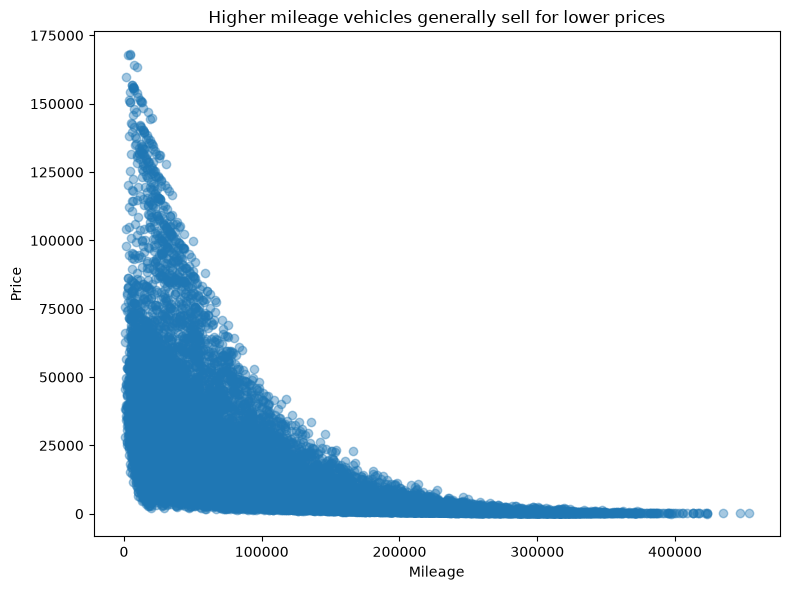

In [44]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_featured["Mileage"],
    df_featured["Price"],
    alpha=0.4
)

plt.title("Higher mileage vehicles generally sell for lower prices")
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.tight_layout()

plt.savefig("../reports/a2_chart2.png", dpi=150, bbox_inches="tight")

plt.show()

### Interpretation

The scatter plot indicates a general negative relationship between mileage and price. Vehicles with higher mileage tend to have lower selling prices, although some variation exists across individual vehicles.

In [45]:
import os

print("Chart 1 exists:",
      os.path.exists("../reports/a2_chart1.png"))

print("Chart 2 exists:",
      os.path.exists("../reports/a2_chart2.png"))

Chart 1 exists: True
Chart 2 exists: True


In [46]:
# Save the cleaned dataset

output_path = "../data/processed/car_sales_data_cleaned.csv"

df_featured.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully.")
print("Location:", output_path)

Cleaned dataset saved successfully.
Location: ../data/processed/car_sales_data_cleaned.csv


In [47]:
print("=" * 50)
print("Assignment 2 Completed Successfully")
print("=" * 50)

print("Final Dataset Shape:", df_featured.shape)

print("\nColumns:")
print(df_featured.columns.tolist())

print("\nDataset saved successfully.")

print("\nCharts saved successfully.")

print("\nNotebook completed and ready for submission.")

Assignment 2 Completed Successfully
Final Dataset Shape: (49988, 11)

Columns:
['Manufacturer', 'Model', 'Engine size', 'Fuel type', 'Year of manufacture', 'Mileage', 'Price', 'Average_Price', 'Average_Mileage', 'Number_of_Cars', 'Standardized_Price']

Dataset saved successfully.

Charts saved successfully.

Notebook completed and ready for submission.


# Final Validation

This final section verifies that the cleaned dataset has been created successfully, the engineered features are present, and the required visualizations have been saved. Running these checks ensures the notebook executes correctly from start to finish before submission.

In [48]:
print("=" * 60)
print("ASSIGNMENT 2 - FINAL SUMMARY")
print("=" * 60)

print("\nFinal dataset shape:")
print(df_featured.shape)

print("\nColumn names:")
print(df_featured.columns.tolist())

ASSIGNMENT 2 - FINAL SUMMARY

Final dataset shape:
(49988, 11)

Column names:
['Manufacturer', 'Model', 'Engine size', 'Fuel type', 'Year of manufacture', 'Mileage', 'Price', 'Average_Price', 'Average_Mileage', 'Number_of_Cars', 'Standardized_Price']


In [49]:
print("Missing values in the final dataset:")

display(df_featured.isna().sum())

Missing values in the final dataset:


Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
Average_Price          0
Average_Mileage        0
Number_of_Cars         0
Standardized_Price     0
dtype: int64

In [50]:
print("First five rows of the final dataset:")

display(df_featured.head())

First five rows of the final dataset:


,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price,Average_Price,Average_Mileage,Number_of_Cars,Standardized_Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074,10671.473455,112525.010029,14956,-0.655095
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704,29103.764661,111638.253737,2609,2.185142
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072,10671.473455,112525.010029,14956,0.623895
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705,14341.099418,111368.922329,12553,-0.738480
4,VW,Polo,1.0,Petrol,2006,127869,4101,10361.781497,113511.216423,14906,-0.592540


In [51]:
import os

processed_dataset = "../data/processed/car_sales_data_cleaned.csv"

if os.path.exists(processed_dataset):
    print("Processed dataset saved successfully.")
else:
    print("Processed dataset was not found.")

Processed dataset saved successfully.


In [52]:
chart1 = "../reports/a2_chart1.png"
chart2 = "../reports/a2_chart2.png"

print("Chart 1 exists:", os.path.exists(chart1))
print("Chart 2 exists:", os.path.exists(chart2))

Chart 1 exists: True
Chart 2 exists: True


In [53]:
print("Dataset Information")

df_featured.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 49988 entries, 0 to 49987
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         49988 non-null  str    
 1   Model                49988 non-null  str    
 2   Engine size          49988 non-null  float64
 3   Fuel type            49988 non-null  str    
 4   Year of manufacture  49988 non-null  int64  
 5   Mileage              49988 non-null  int64  
 6   Price                49988 non-null  int64  
 7   Average_Price        49988 non-null  float64
 8   Average_Mileage      49988 non-null  float64
 9   Number_of_Cars       49988 non-null  int64  
 10  Standardized_Price   49988 non-null  float64
dtypes: float64(4), int64(4), str(3)
memory usage: 4.2 MB
